In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 1.analysis step

In [2]:
df = pd.read_csv("../data/raw/cpi_canada.csv")

In [5]:
df = df.rename(columns={
    "observation_date": "Date",
    "CPALCY01CAM661N": "CPI"
})

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month


In [7]:
annual_cpi = df.groupby("Year")["CPI"].mean()

annual_cpi.head()

Year
1961    13.410413
1962    13.573109
1963    13.795225
1964    14.010267
1965    14.310194
Name: CPI, dtype: float64

In [8]:
annual_cpi = annual_cpi.reset_index()

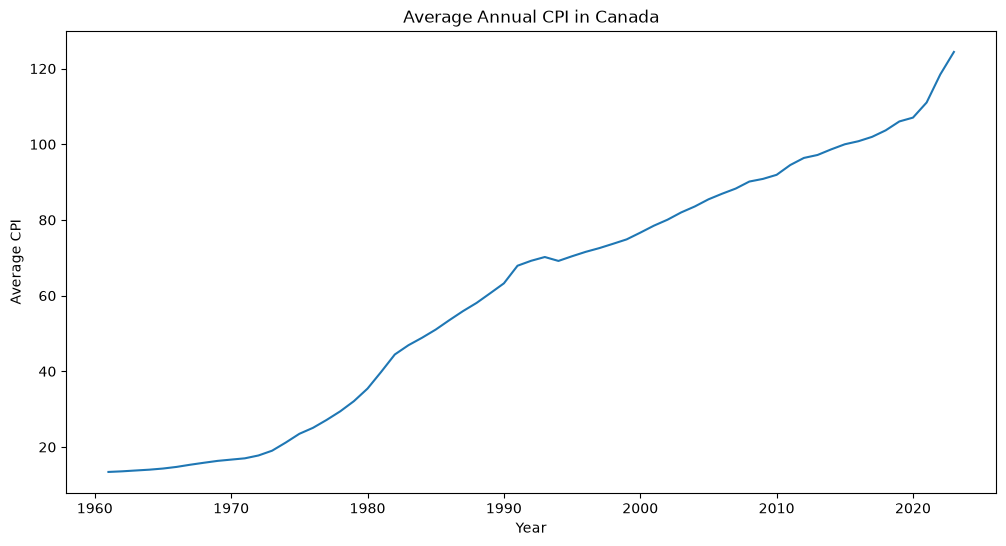

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    annual_cpi["Year"],
    annual_cpi["CPI"]
)

plt.title("Average Annual CPI in Canada")

plt.xlabel("Year")

plt.ylabel("Average CPI")

plt.savefig("../images/annual_cpi.png", dpi=300)

plt.show()

### Graph insight

- The long-term trend shows that Canada's CPI generally increased over the study period.

- Short-term flutuation become less visible after aggregating monthly date into annual averages

### Annual CPI Analysis

Monthly CPI values were grouped by year using `groupby()` and averaged.

Compare to cpi_overtime plot,this reduces short-term fluctuations and highlights long-term trends in Canada's Consumer Price Index over time.The plot become more smooth and clear.

## 2. Correlation step

In [10]:
df[["CPI", "Year", "Month"]].corr()

,CPI,Year,Month
CPI,1.000000,0.991205,0.010554
Year,0.991205,1.000000,-0.003611
Month,0.010554,-0.003611,1.000000


In [11]:
df[["CPI", "Year", "Month"]].corr()["CPI"]

CPI      1.000000
Year     0.991205
Month    0.010554
Name: CPI, dtype: float64

### Correlation Analysis

I calculate the Pearson correlation coefficients among the numerical variables. The result shows that CPI has a strong relationship with Year,reflect the long-term increase in CPI overtime.But the Month show less relation with CPI, suggesting monthly effect is not that strong compare to long-term trend.